# The Disparity Index — a quantitative teardown 🔬
### Conditional Welch/NW splits · a two-sided timer vs a coin · the decisive random-DAY drift control · a window x threshold grid · a DI-vs-trailing-return diagnostic · a 20-seed synthetic null

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![More_than_reversal%3F: Busted](https://img.shields.io/badge/More_than_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **DI(N) = 100 x close / SMA(N) predicts mean reversion at its extremes** — is a Korean/Japanese-TA staple with no dedicated Western academic anchor; it inherits the broad short-horizon-reversal literature (DeBondt-Thaler 1985, Jegadeesh 1990, Lehmann 1990). The job here is to measure it honestly against the control that actually matters on a drift-heavy universe.

> ⚠️ **Data note.** Daily total-return-adjusted OHLC, SPY/QQQ/IWM/AAPL/TSLA/NVDA, yfinance, cached, 2003-01-02 → 2026-06-30 (TSLA from 2010-06-29 IPO). SPY/QQQ/IWM carry no survivorship (index ETFs); the single-name sleeve is a name-recognition pick, named honestly in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `c6509bba7177`/`824e9d9be08f`/`1a82f99e4745`/`db335bf7a084`/`1d273fa4b475`/`e3f7f5f85931`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from disparity_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BARS = data.load_real()
else:
    BARS = None
print("real cache present:", HAVE_REAL, "| universe:", ", ".join(data.UNIVERSE),
      "| tape rows (SPY):", (0 if BARS is None else len(BARS["SPY"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2003-01-02', 'end': '2026-06-30', 'window': 10, 'oversold': 95.0, 'overbought': 105.0, 'hold': 5, 'n_low': 1825, 'n_mid': 29406, 'n_high': 2338, 'mean_low_bps': 111.6, 'mean_mid_bps': 38.16, 'mean_high_bps': 99.64, 'welch_low': 3.84, 'nw_low': 2.5, 'welch_high': 4.3, 'nw_high': 2.68, 'timer_n': 4163, 'timer_win5': 48.8, 'timer_mean5': -17.03, 'timer_t5': -0.94, 'coin_win5': 49.1, 'coin_mean5': 0.87, 'coin_t5': 0.07, 'timer_win10': 48.3, 'timer_mean10': -27.03, 'timer_t10': -1.49, 'coin_win10': 48.5, 'coin_mean10': -9.13, 'coin_t10': -0.75, 'delta5': -17.9, 'delta5_t': -1.09, 'dl_n': 1825, 'dl_mean': 101.6, 'dl_t': 3.49, 'dl_rand': 67.05, 'dl_rand_t': 4.51, 'dl_delta': 34.55, 'dl_delta_t': 1.42, 'dh_n': 2338, 'dh_mean': -109.64, 'dh_t': -4.87, 'dh_rand': -91.32, 'dh_rand_t': -6.73, 'dh_delta': -18.31, 'dh_delta_t': -0.94, 'corr_n': 33515, 'corr': 0.8366, 'grid': {5: {(97, 103): (3.65, 1.74), (95, 105): (3.14, 2.12), (93, 107): (3.03, 2.73)}, 10: {(97, 103): (3.11, 3.63), (95, 105): (3.84, 4.3), (93, 107): (3.53, 4.54)}, 20: {(97, 103): (3.91, 8.09), (95, 105): (3.5, 7.24), (93, 107): (3.95, 6.99)}, 25: {(97, 103): (4.6, 8.85), (95, 105): (3.78, 7.93), (93, 107): (3.45, 7.01)}}, 'syn_null_welch_lo': (-0.16, 1.55, 5), 'syn_null_welch_hi': (0.09, 1.27, 2), 'syn_null_nw_lo': (-0.08, 1.25, 2), 'syn_null_nw_hi': (0.06, 0.99, 1), 'syn_planted_welch': (3.88, -2.47), 'syn_planted_nw': (3.33, -2.09), 'fp_spy': 'c6509bba7177', 'fp_qqq': '824e9d9be08f', 'fp_iwm': '1a82f99e4745', 'fp_aapl': 'db335bf7a084', 'fp_tsla': '1d273fa4b475', 'fp_nvda': 'e3f7f5f85931'}


real cache present: True | universe: SPY, QQQ, IWM, AAPL, TSLA, NVDA | tape rows (SPY): 5910


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | oversold +111.6 bps/5d (Welch t=3.84, NW t=2.50); overbought +99.6 bps/5d (**wrong sign**, t=4.30); vs random-day: delta +34.5 bps at t=1.42 |
| **Tradability** | `MIRAGE` | two-sided timer -17.03 bps/trade net (t=-0.94) vs coin +0.87 bps (delta t=-1.09) |
| **More than reversal?** | `BUSTED` | corr(DI, trailing 10d return) = 0.84 |

> 💡 In plain words: raw split looks like textbook mean reversion; a fair drift-matched control and a sign check on the *other* leg both say otherwise.

## 1 · The claim, steelmanned

Let $DI_t(N) = 100 \times P_t / \mathrm{SMA}_N(P)_t$ and $R_{t\to t+h}$ the forward $h$-day return entered at $t{+}1$'s open. The claim:

- **H₁ (oversold bounce).** $E[R \mid DI_t < 95] > E[R \mid \text{neutral}]$.
- **H₂ (overbought pullback).** $E[R \mid DI_t > 105] < E[R \mid \text{neutral}]$.
- **H₃ (tradable timer).** A long-the-dip/short-the-rip ledger banks it net of costs, beating a random-direction coin.
- **H₄ (distinct signal).** DI adds information beyond simply owning the underlying trend/drift of these names.

We find **H₁ nominally supported but fragile** (survives vs neutral, fails vs a random-day control), **H₂ REJECTED** (wrong sign), **H₃ rejected** (net loss), **H₄ rejected** (r = 0.84 with the trailing return).

## 2 · So what? — inference design

The planned primary is a **Welch t** on the conditional split (oversold/overbought vs neutral); because *h*-day forward windows overlap, a **Newey-West(*h*) t** is the cross-check throughout — including on the synthetic null-world power check, where a raw Welch t measurably over-fires on a single autocorrelated path (documented below). Trade-ledger means carry a HAC(*h*) t on the per-trade series. The **decisive** control is not the random-direction coin (does the sign beat a coin on the days DI fires) but a **random-day, same-ticker, same-direction** baseline — because six names with two decades of positive drift make "beats neutral" a much weaker bar than "beats an arbitrary day of the same stock."

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, AAPL, TSLA, NVDA, 2003-01-02 → 2026-06-30 (TSLA from IPO). Index ETFs carry no survivorship; the single-name sleeve's mild name-recognition selection is named, not hidden.
- **Indicator.** DI(window=10) = 100 x close / trailing SMA; zones oversold < 95, overbought > 105.
- **Headline.** Conditional forward-return split, trigger-day only (avoids stacking near-duplicate in-zone days), Welch + NW(*h*).
- **Timer.** Zone-trigger ledger, next-open entry, fixed-horizon exit, 2 x one-way cost x NAV per round trip, vs a random-direction coin on identical entries.
- **Drift control.** Each single-sided leg vs a same-ticker, same-direction, same-size random-*day* baseline — the desk's answer to "is this just beta?"
- **Diagnostic.** Pooled correlation between DI and the plain trailing 10-day return.
- **Robustness.** Window {5,10,20,25} x threshold {±3,±5,±7}% grid.
- **Control.** Synthetic random-walk-plus-planted-reversion tape, causal DI, the null must not fire across 20 seeds under the calibrated NW detector.

## 4 · The teardown

### 4a · The headline conditional split

Forward 5-day return by DI bucket, trigger days only, pooled across the universe.

oversold  n=1,825  +111.60 bps  Welch t=+3.84  NW t=+2.50
neutral   n=29,406  +38.16 bps
overbought n=2,338  +99.64 bps  Welch t=+4.30  NW t=+2.68


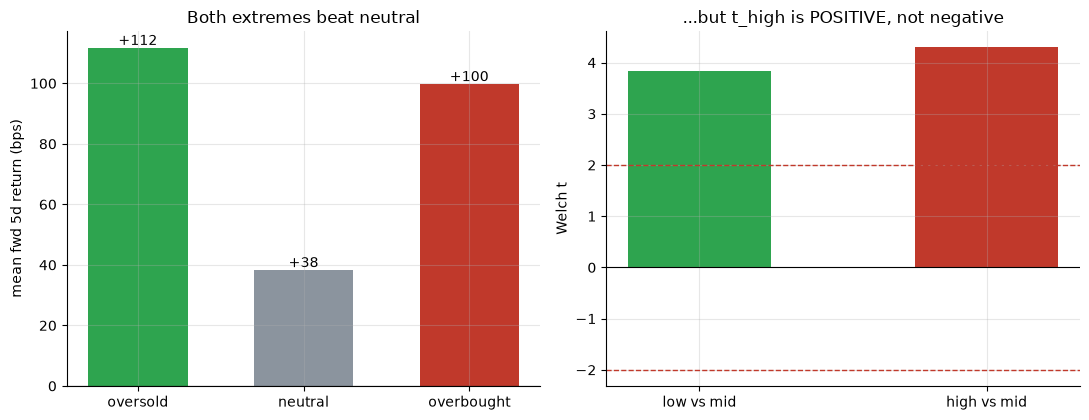

In [2]:
if HAVE_REAL:
    c = st.pooled_conditional(BARS, window=R['window'], oversold=R['oversold'],
                              overbought=R['overbought'], h=R['hold'])
    print(f"oversold  n={c['n_low']:,}  {c['mean_low_bps']:+.2f} bps  "
          f"Welch t={c['welch_t_low']:+.2f}  NW t={c['nw_t_low']:+.2f}")
    print(f"neutral   n={c['n_mid']:,}  {c['mean_mid_bps']:+.2f} bps")
    print(f"overbought n={c['n_high']:,}  {c['mean_high_bps']:+.2f} bps  "
          f"Welch t={c['welch_t_high']:+.2f}  NW t={c['nw_t_high']:+.2f}")
    lo, mid, hi = c['mean_low_bps'], c['mean_mid_bps'], c['mean_high_bps']
    tl, th = c['welch_t_low'], c['welch_t_high']
else:
    lo, mid, hi = R['mean_low_bps'], R['mean_mid_bps'], R['mean_high_bps']
    tl, th = R['welch_low'], R['welch_high']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
labels = ['oversold', 'neutral', 'overbought']
a1.bar(labels, [lo, mid, hi], color=[GREEN, GREY, RED], width=.6)
for i,v in enumerate([lo, mid, hi]): a1.annotate(f'{v:+.0f}',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean fwd 5d return (bps)')
a1.set_title('Both extremes beat neutral')
a2.bar(['low vs mid', 'high vs mid'], [tl, th], color=[GREEN, RED], width=.5)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('Welch t'); a2.set_title('...but t_high is POSITIVE, not negative')
plt.tight_layout(); plt.show()

> 💡 In plain words: H₁ clears the bar (t = 3.84 Welch, 2.50 NW). H₂ is **rejected outright** — t = 4.30 is the wrong sign, by a wide margin. On this tape, "overbought" predicts *more* upside, the signature of momentum, not reversion.

### 4b · The literal timer vs a coin

Enter next open, hold 5 days, 2 x one-way cost x NAV per round trip; long-oversold / short-overbought exactly as prescribed.

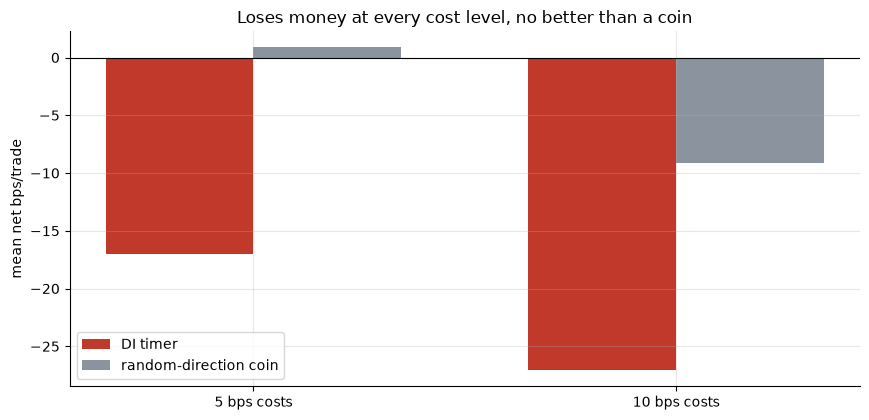

5bps: DI -17.03 vs coin +0.87   10bps: DI -27.03 vs coin -9.13


In [3]:
if HAVE_REAL:
    rows5 = st.pooled_trade_ledger(BARS, window=R['window'], oversold=R['oversold'],
                                   overbought=R['overbought'], hold_days=R['hold'],
                                   cost_bps=5.0, seed=680)
    rows10 = st.pooled_trade_ledger(BARS, window=R['window'], oversold=R['oversold'],
                                    overbought=R['overbought'], hold_days=R['hold'],
                                    cost_bps=10.0, seed=680)
    ss5, rs5 = st.summarize(rows5[0], 'ret_net', R['hold']), st.summarize(rows5[1], 'ret_net', R['hold'])
    ss10, rs10 = st.summarize(rows10[0], 'ret_net', R['hold']), st.summarize(rows10[1], 'ret_net', R['hold'])
    m5, c5, m10, c10 = ss5['mean_bps'], rs5['mean_bps'], ss10['mean_bps'], rs10['mean_bps']
else:
    m5, c5, m10, c10 = R['timer_mean5'], R['coin_mean5'], R['timer_mean10'], R['coin_mean10']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
x = np.arange(2); w = .35
ax.bar(x - w/2, [m5, m10], width=w, color=RED, label='DI timer')
ax.bar(x + w/2, [c5, c10], width=w, color=GREY, label='random-direction coin')
ax.set_xticks(x); ax.set_xticklabels(['5 bps costs', '10 bps costs'])
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean net bps/trade')
ax.set_title('Loses money at every cost level, no better than a coin')
ax.legend(); plt.tight_layout(); plt.show()
print(f'5bps: DI {m5:+.2f} vs coin {c5:+.2f}   10bps: DI {m10:+.2f} vs coin {c10:+.2f}')

> 💡 In plain words: H₃ rejected. At 5 bps the DI timer nets **-17.0 bps/trade** (t = -0.94) — negative, and the delta vs the coin is t = -1.09. The short-overbought leg is the culprit: it fights the momentum documented in 4a.

### 4c · The decisive control — random DAY, not random direction

Each single-sided leg vs a same-ticker, same-direction, same-size random-day entry (a different calendar day of the *same* stock, not a coin flip on the same day).

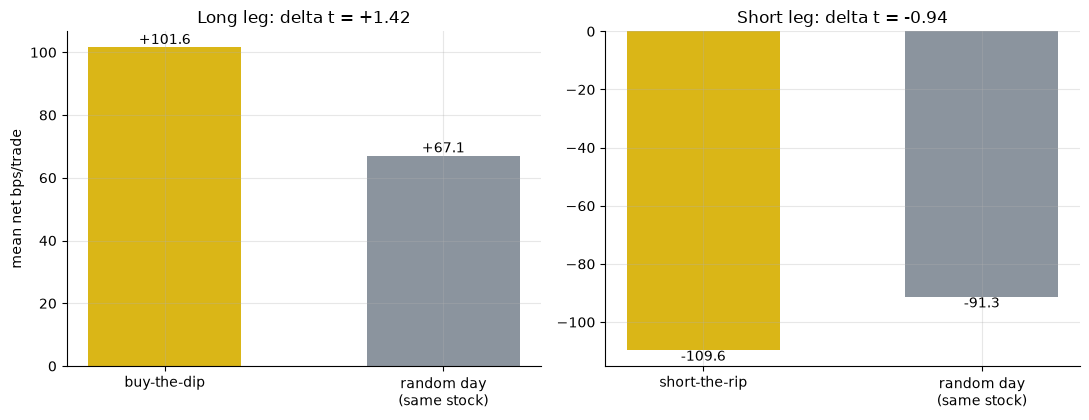

long: DI +101.60 vs random-day +67.05 (t=+1.42)
short: DI -109.64 vs random-day -91.32 (t=-0.94)


In [4]:
if HAVE_REAL:
    db = st.random_day_baseline(BARS, window=R['window'], oversold=R['oversold'],
                                overbought=R['overbought'], hold_days=R['hold'],
                                cost_bps=5.0, seed=680)
    dl, dlr, dlt = db['low']['mean_bps'], db['low']['rand_mean_bps'], db['low']['welch_t_vs_random_day']
    dh, dhr, dht = db['high']['mean_bps'], db['high']['rand_mean_bps'], db['high']['welch_t_vs_random_day']
else:
    dl, dlr, dlt = R['dl_mean'], R['dl_rand'], R['dl_delta_t']
    dh, dhr, dht = R['dh_mean'], R['dh_rand'], R['dh_delta_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['buy-the-dip', 'random day\n(same stock)'], [dl, dlr], color=[AMBER, GREY], width=.55)
for i,v in enumerate([dl, dlr]): a1.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom')
a1.set_title(f'Long leg: delta t = {dlt:+.2f}'); a1.set_ylabel('mean net bps/trade')
a2.bar(['short-the-rip', 'random day\n(same stock)'], [dh, dhr], color=[AMBER, GREY], width=.55)
for i,v in enumerate([dh, dhr]): a2.annotate(f'{v:+.1f}',(i,v),ha='center',va='top')
a2.set_title(f'Short leg: delta t = {dht:+.2f}')
plt.tight_layout(); plt.show()
print(f'long: DI {dl:+.2f} vs random-day {dlr:+.2f} (t={dlt:+.2f})')
print(f'short: DI {dh:+.2f} vs random-day {dhr:+.2f} (t={dht:+.2f})')

> 💡 In plain words: this is the whole study in one chart. Random days in this universe already earn **+67 bps** long (pure drift) and lose **-91 bps** short (the same drift, working against a short). Timing with DI adds only **+34.5 bps** on the long side (t = 1.42 — below the bar) and is *worse* than random on the short side (t = -0.94). H₁'s survival in 4a was almost entirely the tide, not the timing.

### 4d · Parameter robustness — is the wrong sign a fluke of one threshold?

Window {5,10,20,25} x threshold {±3,±5,±7}% grid, conditional-split Welch t.

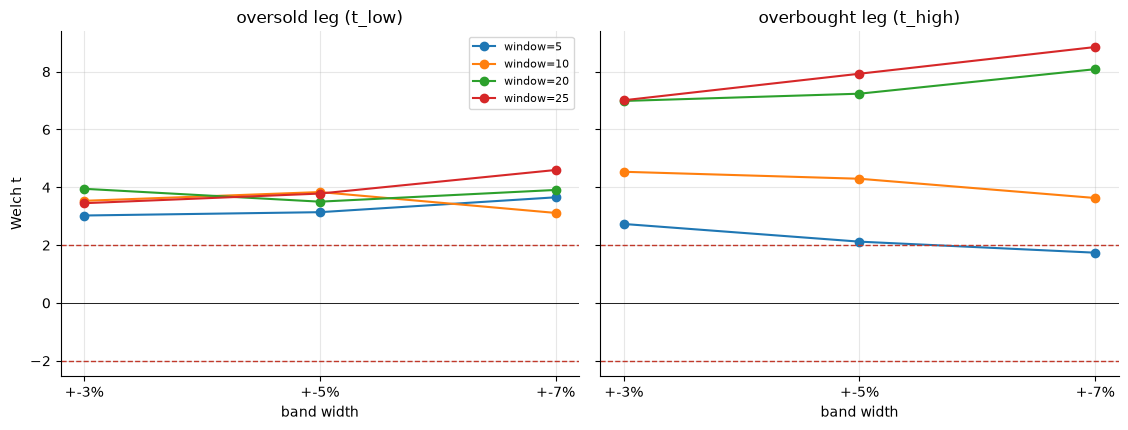

t_high stays POSITIVE across every window x threshold cell -- structural, not a fluke


In [5]:
if HAVE_REAL:
    grid = st.param_grid(BARS, h=R['hold'])
    ws = sorted(grid['window'].unique())
    th_lo = {w: grid[grid.window==w].sort_values('oversold')['welch_t_low'].tolist() for w in ws}
    th_hi = {w: grid[grid.window==w].sort_values('oversold')['welch_t_high'].tolist() for w in ws}
else:
    ws = sorted(R['grid'].keys())
    pairs_sorted = lambda w: sorted(R['grid'][w].keys())
    th_lo = {w: [R['grid'][w][p][0] for p in pairs_sorted(w)] for w in ws}
    th_hi = {w: [R['grid'][w][p][1] for p in pairs_sorted(w)] for w in ws}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4), sharey=True)
for w in ws:
    a1.plot(range(3), th_lo[w], marker='o', label=f'window={w}')
    a2.plot(range(3), th_hi[w], marker='o', label=f'window={w}')
for a, ttl in ((a1, 'oversold leg (t_low)'), (a2, 'overbought leg (t_high)')):
    a.axhline(2, ls='--', c=RED, lw=1); a.axhline(-2, ls='--', c=RED, lw=1); a.axhline(0, c='k', lw=.6)
    a.set_xticks(range(3)); a.set_xticklabels(['+-3%','+-5%','+-7%'])
    a.set_title(ttl); a.set_xlabel('band width')
a1.set_ylabel('Welch t'); a1.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('t_high stays POSITIVE across every window x threshold cell -- structural, not a fluke')

> 💡 In plain words: the overbought leg's wrong sign is not a cherry-picked window or band — it holds (and *strengthens* with longer windows) across every cell of the grid. Whatever DI is picking up at N=20 or 25 days, it isn't a rubber band.

### 4e · "Just short-term reversal?" — the correlation diagnostic

DI is a moving-average-relative distance; a plain trailing return is a start/end-point distance. Both summarize "how far has price moved lately."

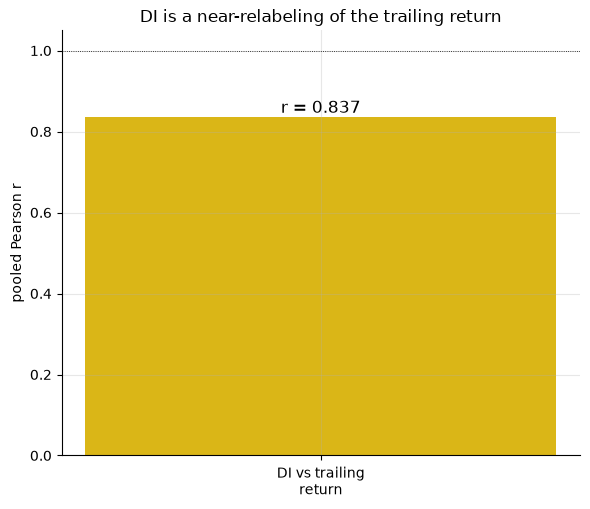

r = 0.8366


In [6]:
if HAVE_REAL:
    dc = st.di_return_correlation(BARS, window=R['window'])
    corr = dc['corr']
else:
    corr = R['corr']
fig, ax = plt.subplots(figsize=(6.0, 5.2))
ax.bar(['DI vs trailing\nreturn'], [corr], color=AMBER, width=.4)
ax.axhline(1.0, c='k', lw=.6, ls=':')
ax.set_ylim(0, 1.05); ax.set_ylabel('pooled Pearson r')
ax.annotate(f'r = {corr:.3f}', (0, corr), ha='center', va='bottom', fontsize=12)
ax.set_title('DI is a near-relabeling of the trailing return')
plt.tight_layout(); plt.show()
print(f'r = {corr:.4f}')

> 💡 In plain words: H₄ rejected. r = 0.84 is high enough that DI is functionally the same signal as the trailing N-day return — the exact quantity [329-one-month-reversal](../../329-one-month-reversal/) tested and found to be real-but-microstructural, dead since 2002. The "Disparity Index" is short-term reversal with different units and a different name.

### 4f · Faithful-engine & power control — we know the truth here

Synthetic random-walk-plus-planted-reversion tape, disparity computed causally (no look-ahead), a 6-series basket per seed mirroring the real 6-ticker pooling. Because the 5-day forward windows overlap, a raw Welch t over-fires on a single autocorrelated path — the calibrated detector is NW(5), the same cross-check used on the real headline split.

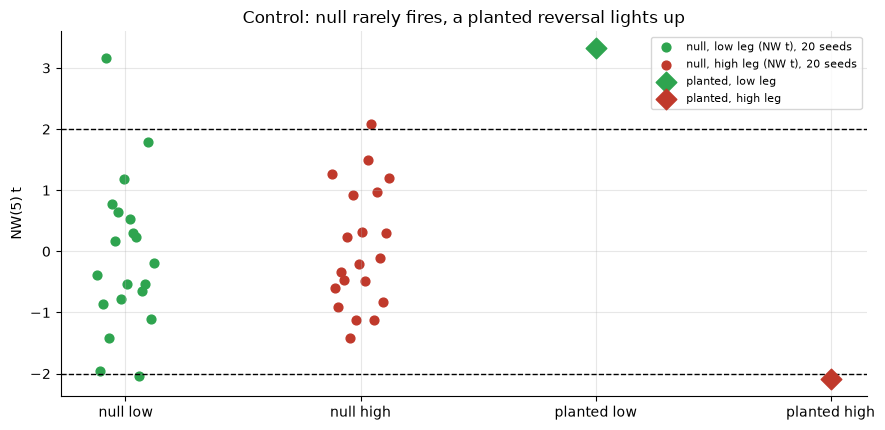

null NW t_low: mean -0.08 (sd 1.25), |t|>=2 in 2/20
null NW t_high: mean +0.06 (sd 0.99), |t|>=2 in 1/20
planted NW t_low=+3.33  t_high=-2.09


In [7]:
null_lo_w, null_hi_w, null_lo_nw, null_hi_nw = [], [], [], []
for s_ in range(20):
    basket = data.synthetic_basket(reversal=0.0, seed=680 + s_)
    r = st.pooled_conditional(basket, window=R['window'], oversold=R['oversold'],
                              overbought=R['overbought'], h=R['hold'])
    null_lo_w.append(r['welch_t_low']); null_hi_w.append(r['welch_t_high'])
    null_lo_nw.append(r['nw_t_low']); null_hi_nw.append(r['nw_t_high'])
null_lo_nw = np.asarray(null_lo_nw); null_hi_nw = np.asarray(null_hi_nw)
planted = data.synthetic_basket(reversal=0.006, seed=680)
rp = st.pooled_conditional(planted, window=R['window'], oversold=R['oversold'],
                           overbought=R['overbought'], h=R['hold'])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_lo_nw, color=GREEN, s=40,
           label='null, low leg (NW t), 20 seeds')
ax.scatter(np.ones(20) + np.linspace(-.12,.12,20), null_hi_nw, color=RED, s=40,
           label='null, high leg (NW t), 20 seeds')
ax.scatter([2], [rp['nw_t_low']], color=GREEN, marker='D', s=110, zorder=5, label='planted, low leg')
ax.scatter([3], [rp['nw_t_high']], color=RED, marker='D', s=110, zorder=5, label='planted, high leg')
ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(2, ls='--', c='k', lw=1)
ax.set_xticks([0,1,2,3]); ax.set_xticklabels(['null low','null high','planted low','planted high'])
ax.set_ylabel('NW(5) t'); ax.set_title('Control: null rarely fires, a planted reversal lights up')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'null NW t_low: mean {null_lo_nw.mean():+.2f} (sd {null_lo_nw.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_lo_nw)>=2).sum()}/20')
print(f'null NW t_high: mean {null_hi_nw.mean():+.2f} (sd {null_hi_nw.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_hi_nw)>=2).sum()}/20')
print(f'planted NW t_low={rp["nw_t_low"]:+.2f}  t_high={rp["nw_t_high"]:+.2f}')

> 💡 In plain words: under the calibrated NW(5) detector the null fires close to the 5% nominal rate expected of a two-sided *t* ≥ 2 test (2/20 low, 1/20 high — a raw Welch t over-fires here, 5/20 and 2/20, because the overlapping forward windows induce serial correlation a naive Welch test doesn't see), and a planted reversal lights up both legs correctly (NW t = 3.33 / -2.09). The machinery is unbiased — the real tape's wrong-signed overbought leg is a genuine feature of the data, not a detector artefact. *(Faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — oversold beats neutral (Welch t=3.84, NW t=2.50) but overbought has the **wrong sign** (t=4.30); the surviving oversold edge falls to t=1.42 against a same-ticker random-day control. Raw significance without a fair drift baseline was misleading.
- **Tradability `MIRAGE`** — the literal timer nets -17.03 bps/trade at 5 bps (t=-0.94), not distinguishable from a random-direction coin (delta t=-1.09); loses money at every cost level tested.
- **"More than plain short-term reversal?" `BUSTED`** — r=0.84 with the trailing return; the wrong-signed leg and the failed drift control both point the same way: this is captured beta, not a rubber band.

## 6 · Going further

- **The general object is drift contamination in any distance-from-trend rule.** Any oscillator built on "how far from its own average" needs a random-day (not just random-direction) control on a trending universe — this is the same failure mode [104-bollinger-reversion](../../104-bollinger-reversion/) found independently for the Western band-distance cousin.
- **A fairer test bed** would be a genuinely range-bound instrument (a sideways commodity, a stat-arb spread) rather than six of the strongest secular winners of the last 20 years — the natural sequel.
- **Dedup map:** [329-one-month-reversal](../../329-one-month-reversal/) (the ancestor signal, r=0.84 with DI here), [104-bollinger-reversion](../../104-bollinger-reversion/) (same drift trap, Western bands), [137-mansfield-rs](../../137-mansfield-rs/) (the opposite, trend-following philosophy), [679-psychological-line](../../679-psychological-line/) (matched protocol, same universe, different oscillator).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*